In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'


In [2]:
import time
import torch
from typing import Iterable, Optional, Tuple, Dict, Any
import numpy as np
import torch
import matplotlib.pyplot as plt
import lightgbm as lgb

from utils.inferences import *

from utils.Encoder_model import make_Encoder_model

## LightGBM and CatBoost utilities

In [3]:
from catboost import CatBoostRanker, Pool

_catboost_model_cache: Dict[int, CatBoostRanker] = {}

def get_catboost_ranker(num_features: int) -> CatBoostRanker:
    """Returns (and caches) a tiny CatBoost ranker for benchmark purposes."""
    global _catboost_model_cache

    if num_features in _catboost_model_cache:
        return _catboost_model_cache[num_features]

    rng = np.random.default_rng(123 + num_features)

    docs_per_group = 32
    num_groups = 64
    n_samples = docs_per_group * num_groups

    X = rng.normal(size=(n_samples, num_features)).astype(np.float32)
    y = rng.integers(0, 5, size=n_samples).astype(np.float32)
    group_id = np.repeat(np.arange(num_groups), docs_per_group)

    train_pool = Pool(
        data=X,
        label=y,
        group_id=group_id
    )

    model = CatBoostRanker(
        # iterations=50,
        depth=10,
        learning_rate=0.1,
        loss_function='YetiRank',   # CatBoost ranking loss
        verbose=False,
        random_seed=42,
        n_estimators=20
        # task_type='gpu'
        
    )

    model.fit(train_pool)

    _catboost_model_cache[num_features] = model
    return model


def measure_catboost_inference_time(
    ranker: CatBoostRanker,
    num_docs: int,
    num_features: int,
    repeats: int = 30,
) -> Dict[str, float]:
    """Latency benchmark for a fitted CatBoostRanker (wall-clock only)."""
    sample = np.random.randn(num_docs, num_features).astype(np.float32)
    pool = Pool(sample)

    wall_ms = []
    for _ in range(max(1, repeats)):
        t0 = time.perf_counter()
        _ = ranker.predict(pool)
        t1 = time.perf_counter()
        wall_ms.append((t1 - t0) * 1000.0)

    return {
        'wall_ms_avg': float(np.mean(wall_ms)),
        'wall_ms_p95': float(np.percentile(wall_ms, 95)),
    }


In [4]:
# LightGBM helper utilities
_lightgbm_model_cache: Dict[Tuple[int, str], lgb.LGBMRanker] = {}


def get_lightgbm_ranker(num_features: int, device_type: str = 'cpu') -> lgb.LGBMRanker:
    """Returns (and caches) a tiny LightGBM ranker for the requested feature size."""
    key = (num_features, device_type)
    if key in _lightgbm_model_cache:
        return _lightgbm_model_cache[key]

    rng = np.random.default_rng(42 + num_features)
    docs_per_group = 32
    num_groups = 64
    X = rng.normal(size=(docs_per_group * num_groups, num_features)).astype(np.float32)
    y = rng.integers(low=0, high=5, size=docs_per_group * num_groups, dtype=np.int32)
    group = np.full(num_groups, docs_per_group, dtype=np.int32)

    ranker = lgb.LGBMRanker(
        objective='lambdarank',
        metric='ndcg',
        n_estimators=20,
        num_leaves=10,
        learning_rate=0.1,
        device_type=device_type,
        verbosity=-1,
        random_state=42,
    )
    try:
        ranker.fit(X, y, group=group)
    except lgb.basic.LightGBMError as exc:
        if device_type == 'gpu':
            raise RuntimeError('LightGBM was not compiled with GPU support in this environment.') from exc
        raise

    _lightgbm_model_cache[key] = ranker
    return ranker


def measure_lightgbm_inference_time(
    ranker: lgb.LGBMRanker,
    num_docs: int,
    num_features: int,
    repeats: int = 30,
) -> Dict[str, float]:
    """Latency benchmark for a fitted LightGBM ranker (wall-clock only)."""
    sample = np.random.randn(num_docs, num_features).astype(np.float32)
    wall_ms = []
    for _ in range(max(1, repeats)):
        t0 = time.perf_counter()
        _ = ranker.predict(sample)
        t1 = time.perf_counter()
        wall_ms.append((t1 - t0) * 1000.0)
    return {
        'wall_ms_avg': float(np.mean(wall_ms)),
        'wall_ms_p95': float(np.percentile(wall_ms, 95)),
    }



## Inference plots

/home/aletovv/anaconda3/envs/ltr/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/aletovv/anaconda3/envs/ltr/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/aletovv/anaconda3/envs/ltr/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/aletovv/anaconda3/envs/ltr/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/aletovv/anaconda3/envs/ltr/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRanker was fit

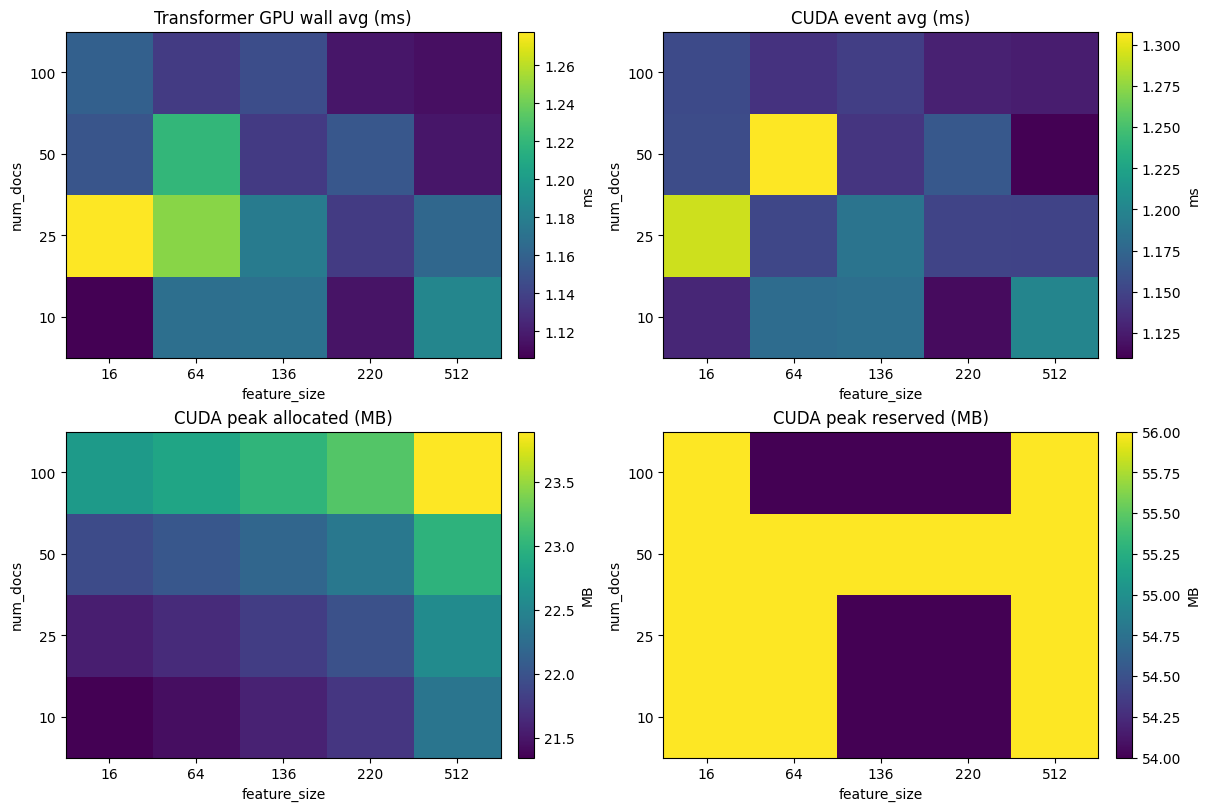

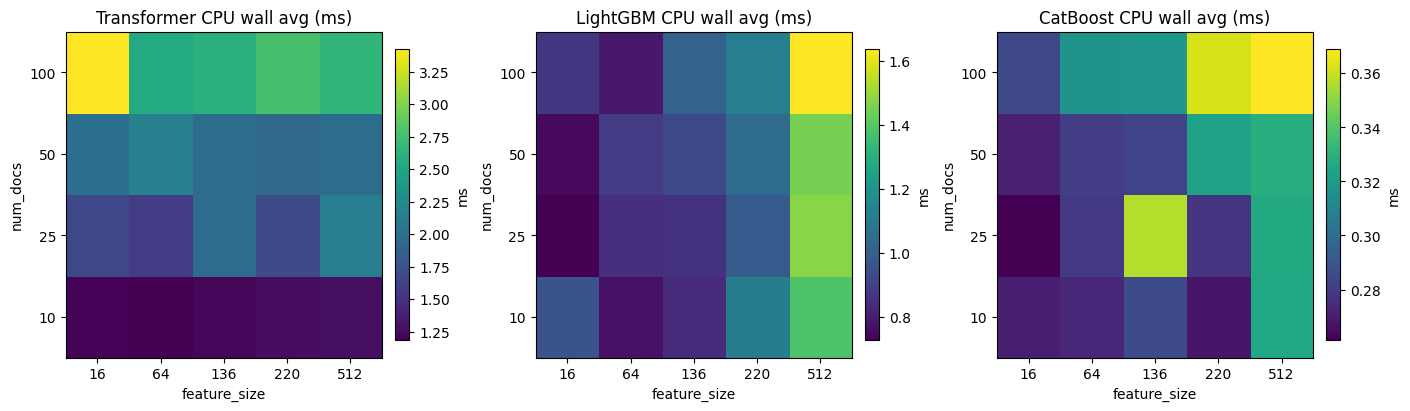

In [8]:
# Parameter grid (edit as needed)
doc_counts = [10, 25, 50, 100]
feature_sizes = [16, 64, 136, 220, 512]
repeats = 5

has_cuda = torch.cuda.is_available()
device_gpu = torch.device('cuda') if has_cuda else torch.device('cpu')
device_cpu = torch.device('cpu')

shape = (len(doc_counts), len(feature_sizes))
wall_gpu = np.full(shape, np.nan, dtype=float)
event_gpu = np.full(shape, np.nan, dtype=float)
mem_alloc_mb = np.full(shape, np.nan, dtype=float)
mem_resv_mb = np.full(shape, np.nan, dtype=float)
wall_cpu = np.full(shape, np.nan, dtype=float)
lightgbm_cpu = np.full(shape, np.nan, dtype=float)
cpu_speed_ratio = np.full(shape, np.nan, dtype=float)
catboost_cpu = np.full(shape, np.nan, dtype=float)
cpu_tf_vs_cat = np.full(shape, np.nan, dtype=float)


# Sweep
for i, nd in enumerate(doc_counts):
    for j, fs in enumerate(feature_sizes):
        if has_cuda:
            model_gpu = make_Encoder_model(input_dim=fs).to(device_gpu)
            x_gpu = torch.randn((1, nd, fs), device=device_gpu)
            t_res_gpu = measure_inference_time(model_gpu, x_gpu, repeats=repeats, use_cuda_events=True)
            wall_gpu[i, j] = t_res_gpu['wall_ms_avg']
            event_gpu[i, j] = t_res_gpu['event_ms_avg'] if t_res_gpu['event_ms_avg'] is not None else np.nan
            m_res = measure_inference_peak_memory(model_gpu, x_gpu, steps=3)
            mem_alloc_mb[i, j] = m_res['cuda_peak']['allocated_bytes'] / (1024**2)
            mem_resv_mb[i, j] = m_res['cuda_peak']['reserved_bytes'] / (1024**2)

        model_cpu = make_Encoder_model(input_dim=fs).to(device_cpu)
        x_cpu = torch.randn((1, nd, fs), device=device_cpu)
        t_res_cpu = measure_inference_time(model_cpu, x_cpu, repeats=repeats, use_cuda_events=False)
        wall_cpu[i, j] = t_res_cpu['wall_ms_avg']

        lgb_ranker = get_lightgbm_ranker(fs, device_type='cpu')
        lgb_res = measure_lightgbm_inference_time(lgb_ranker, nd, fs, repeats=repeats)
        lightgbm_cpu[i, j] = lgb_res['wall_ms_avg']

        if lightgbm_cpu[i, j] > 0:
            cpu_speed_ratio[i, j] = wall_cpu[i, j] / lightgbm_cpu[i, j]
            
        cat_ranker = get_catboost_ranker(fs)
        cat_res = measure_catboost_inference_time(cat_ranker, nd, fs, repeats=repeats)
        catboost_cpu[i, j] = cat_res['wall_ms_avg']

        if catboost_cpu[i, j] > 0:
            cpu_tf_vs_cat[i, j] = wall_cpu[i, j] / catboost_cpu[i, j]
        else:
            cpu_tf_vs_cat[i, j] = np.nan

# Plot helpers
def plot_heatmap(ax, Z, x_ticks, y_ticks, title, cbar_label):
    im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis')
    ax.set_xticks(np.arange(len(x_ticks)))
    ax.set_xticklabels(x_ticks)
    ax.set_yticks(np.arange(len(y_ticks)))
    ax.set_yticklabels(y_ticks)
    ax.set_xlabel('feature_size')
    ax.set_ylabel('num_docs')
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

if has_cuda:
    fig_gpu, axes_gpu = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    plot_heatmap(axes_gpu[0, 0], wall_gpu, feature_sizes, doc_counts, 'Transformer GPU wall avg (ms)', 'ms')
    plot_heatmap(axes_gpu[0, 1], event_gpu, feature_sizes, doc_counts, 'CUDA event avg (ms)', 'ms')
    plot_heatmap(axes_gpu[1, 0], mem_alloc_mb, feature_sizes, doc_counts, 'CUDA peak allocated (MB)', 'MB')
    plot_heatmap(axes_gpu[1, 1], mem_resv_mb, feature_sizes, doc_counts, 'CUDA peak reserved (MB)', 'MB')
    plt.show()
    fig_gpu.savefig('inference.pdf')
else:
    print('CUDA device not available; skipped GPU latency/memory plots.')

fig_cpu, axes_cpu = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
plot_heatmap(axes_cpu[0], wall_cpu, feature_sizes, doc_counts, 'Transformer CPU wall avg (ms)', 'ms')
plot_heatmap(axes_cpu[1], lightgbm_cpu, feature_sizes, doc_counts, 'LightGBM CPU wall avg (ms)', 'ms')
plot_heatmap(axes_cpu[2], catboost_cpu, feature_sizes, doc_counts,
             'CatBoost CPU wall avg (ms)', 'ms')

plt.show()
fig_cpu.savefig('inference_cpu_vs_lightgbm.pdf')



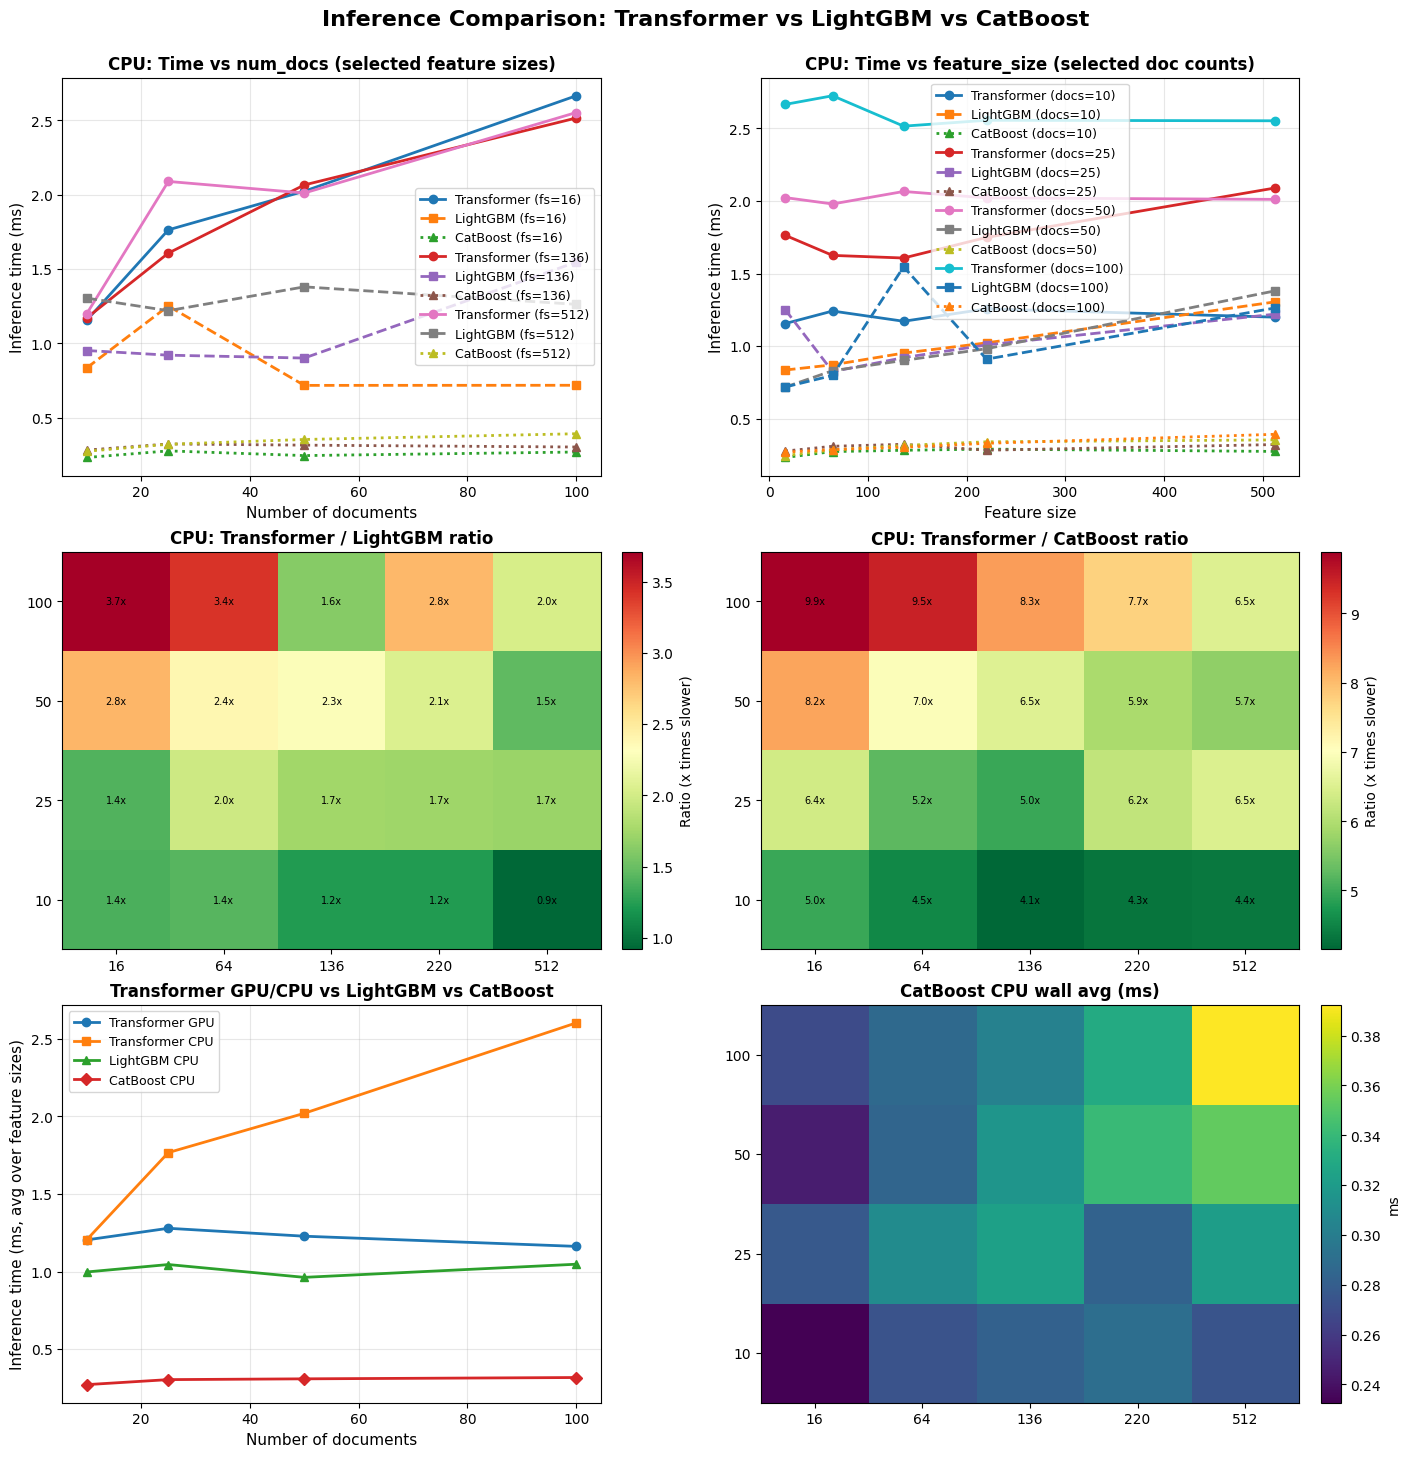

In [ ]:

fig, axes = plt.subplots(3, 2, figsize=(14, 14), constrained_layout=True)

selected_feature_indices = [0, 2, 4] if len(feature_sizes) > 4 else range(len(feature_sizes))
for idx in selected_feature_indices:
    fs = feature_sizes[idx]
    axes[0, 0].plot(doc_counts, wall_cpu[:, idx], marker='o', label=f'Transformer (fs={fs})', linewidth=2)
    axes[0, 0].plot(doc_counts, lightgbm_cpu[:, idx], marker='s', linestyle='--', label=f'LightGBM (fs={fs})', linewidth=2)
    axes[0, 0].plot(doc_counts, catboost_cpu[:, idx], marker='^', linestyle=':', label=f'CatBoost (fs={fs})', linewidth=2)

axes[0, 0].set_xlabel('Number of documents', fontsize=11)
axes[0, 0].set_ylabel('Inference time (ms)', fontsize=11)
axes[0, 0].set_title('CPU: Time vs num_docs (selected feature sizes)', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

selected_doc_indices = [1, 3] if len(doc_counts) > 4 else range(len(doc_counts))
for idx in selected_doc_indices:
    nd = doc_counts[idx]
    axes[0, 1].plot(feature_sizes, wall_cpu[idx, :], marker='o', label=f'Transformer (docs={nd})', linewidth=2)
    axes[0, 1].plot(feature_sizes, lightgbm_cpu[idx, :], marker='s', linestyle='--', label=f'LightGBM (docs={nd})', linewidth=2)
    axes[0, 1].plot(feature_sizes, catboost_cpu[idx, :], marker='^', linestyle=':', label=f'CatBoost (docs={nd})', linewidth=2)

axes[0, 1].set_xlabel('Feature size', fontsize=11)
axes[0, 1].set_ylabel('Inference time (ms)', fontsize=11)
axes[0, 1].set_title('CPU: Time vs feature_size (selected doc counts)', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

im1 = axes[1, 0].imshow(cpu_speed_ratio, origin='lower', aspect='auto', cmap='RdYlGn_r')
axes[1, 0].set_xticks(np.arange(len(feature_sizes)))
axes[1, 0].set_xticklabels(feature_sizes)
axes[1, 0].set_yticks(np.arange(len(doc_counts)))
axes[1, 0].set_yticklabels(doc_counts)
axes[1, 0].set_title('CPU: Transformer / LightGBM ratio', fontsize=12, fontweight='bold')

cbar1 = plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)
cbar1.set_label('Ratio (x times slower)', fontsize=10)

# Annotate
for i in range(len(doc_counts)):
    for j in range(len(feature_sizes)):
        if not np.isnan(cpu_speed_ratio[i, j]):
            axes[1, 0].text(j, i, f'{cpu_speed_ratio[i, j]:.1f}x',
                            ha="center", va="center", fontsize=7)

im2 = axes[1, 1].imshow(cpu_tf_vs_cat, origin='lower', aspect='auto', cmap='RdYlGn_r')
axes[1, 1].set_xticks(np.arange(len(feature_sizes)))
axes[1, 1].set_xticklabels(feature_sizes)
axes[1, 1].set_yticks(np.arange(len(doc_counts)))
axes[1, 1].set_yticklabels(doc_counts)
axes[1, 1].set_title('CPU: Transformer / CatBoost ratio', fontsize=12, fontweight='bold')

cbar2 = plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)
cbar2.set_label('Ratio (x times slower)', fontsize=10)

for i in range(len(doc_counts)):
    for j in range(len(feature_sizes)):
        if not np.isnan(cpu_tf_vs_cat[i, j]):
            axes[1, 1].text(j, i, f'{cpu_tf_vs_cat[i, j]:.1f}x',
                            ha="center", va="center", fontsize=7)

wall_cpu_avg = np.nanmean(wall_cpu, axis=1)
lgb_cpu_avg = np.nanmean(lightgbm_cpu, axis=1)
cat_cpu_avg = np.nanmean(catboost_cpu, axis=1)

if has_cuda:
    wall_gpu_avg = np.nanmean(wall_gpu, axis=1)
    axes[2, 0].plot(doc_counts, wall_gpu_avg, marker='o', label='Transformer GPU', linewidth=2)
else:
    axes[2, 0].plot(doc_counts, wall_cpu_avg, marker='o', label='Transformer CPU', linewidth=2)

axes[2, 0].plot(doc_counts, wall_cpu_avg, marker='s', label='Transformer CPU', linewidth=2)
axes[2, 0].plot(doc_counts, lgb_cpu_avg, marker='^', label='LightGBM CPU', linewidth=2)
axes[2, 0].plot(doc_counts, cat_cpu_avg, marker='D', label='CatBoost CPU', linewidth=2)

axes[2, 0].set_xlabel('Number of documents', fontsize=11)
axes[2, 0].set_ylabel('Inference time (ms, avg over feature sizes)', fontsize=11)
axes[2, 0].set_title('Transformer GPU/CPU vs LightGBM vs CatBoost', fontsize=12, fontweight='bold')
axes[2, 0].legend(fontsize=9)
axes[2, 0].grid(True, alpha=0.3)

im3 = axes[2, 1].imshow(catboost_cpu, origin='lower', aspect='auto', cmap='viridis')
axes[2, 1].set_xticks(np.arange(len(feature_sizes)))
axes[2, 1].set_xticklabels(feature_sizes)
axes[2, 1].set_yticks(np.arange(len(doc_counts)))
axes[2, 1].set_yticklabels(doc_counts)
axes[2, 1].set_title('CatBoost CPU wall avg (ms)', fontsize=12, fontweight='bold')

cbar3 = plt.colorbar(im3, ax=axes[2, 1], fraction=0.046, pad=0.04)
cbar3.set_label('ms')

plt.suptitle('Inference Comparison: Transformer vs LightGBM vs CatBoost', fontsize=16, fontweight='bold', y=1.03)
plt.show()
fig.savefig('inference_comparison_extended.pdf', dpi=150, bbox_inches='tight')


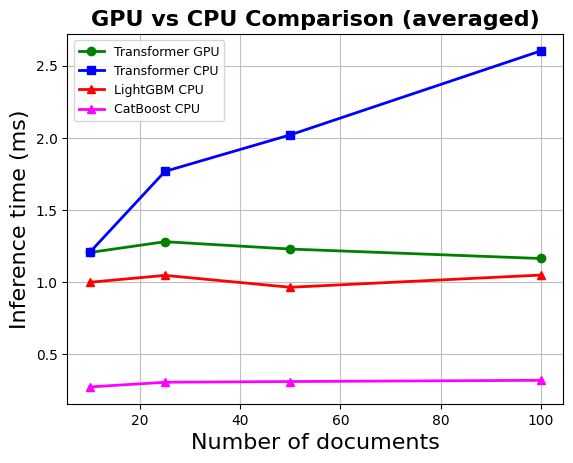

In [10]:
wall_gpu_avg = np.nanmean(wall_gpu, axis=1)
wall_cpu_avg = np.nanmean(wall_cpu, axis=1)
plt.plot(doc_counts, wall_gpu_avg, marker='o', label='Transformer GPU', linewidth=2, color='green')
plt.plot(doc_counts, wall_cpu_avg, marker='s', label='Transformer CPU', linewidth=2, color='blue')
plt.plot(doc_counts, np.nanmean(lightgbm_cpu, axis=1), marker='^', label='LightGBM CPU', linewidth=2, color='red')
plt.plot(doc_counts, np.nanmean(catboost_cpu, axis=1), marker='^', label='CatBoost CPU', linewidth=2, color='magenta')
plt.xlabel('Number of documents', fontsize=16)
plt.ylabel('Inference time (ms)', fontsize=16)
plt.title('GPU vs CPU Comparison (averaged)', fontsize=16, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.8)
# plt.yscale('log')
plt.savefig('inference_gpu_vs_cpu_comparison.pdf', dpi=150, bbox_inches='tight')